<a href="https://colab.research.google.com/github/sunkaravivek/ML-23CSE302/blob/main/lab-7/7.6_decision_trees-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('/content/house_data.csv')

print(data.shape)
print(data.head())

(20, 3)
   Age  Income  Buy_House
0   22   25000          0
1   25   30000          0
2   28   35000          0
3   30   40000          0
4   32   45000          1


In [ ]:
print(data.isnull().sum())

Age          0
Income       0
Buy_House    0
dtype: int64


In [ ]:
X = data[['Age', 'Income']]
y = data['Buy_House']

print(X)
print(y)

    Age  Income
0    22   25000
1    25   30000
2    28   35000
3    30   40000
4    32   45000
5    35   50000
6    38   55000
7    40   60000
8    42   65000
9    45   70000
10   48   75000
11   50   80000
12   52   85000
13   55   90000
14   58   95000
15   60  100000
16   27   40000
17   33   55000
18   44   70000
19   37   60000
0     0
1     0
2     0
3     0
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    0
17    1
18    1
19    1
Name: Buy_House, dtype: int64


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1
)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(16, 2)
(4, 2)
(16,)
(4,)


In [ ]:
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=5
)

model.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=5)

In [ ]:
y_pred = model.predict(x_test)

print("Predicted values:")
print(y_pred)

Predicted values:
[0 0 1 1]


In [ ]:
accuracy_score = metrics.accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy_score)
print("Accuracy in Percentage :", int(accuracy_score * 100), "%")

Accuracy Score : 1.0
Accuracy in Percentage : 100 %


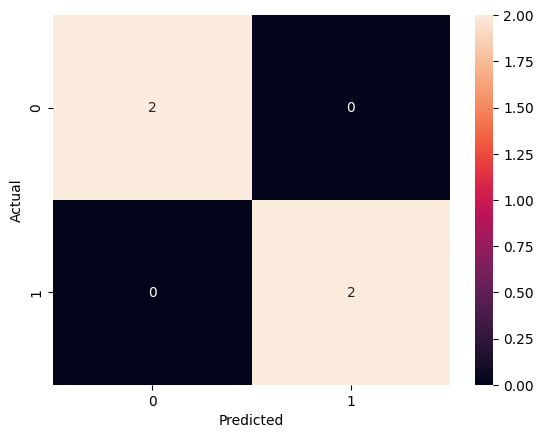

In [ ]:
conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True)
plt.show()

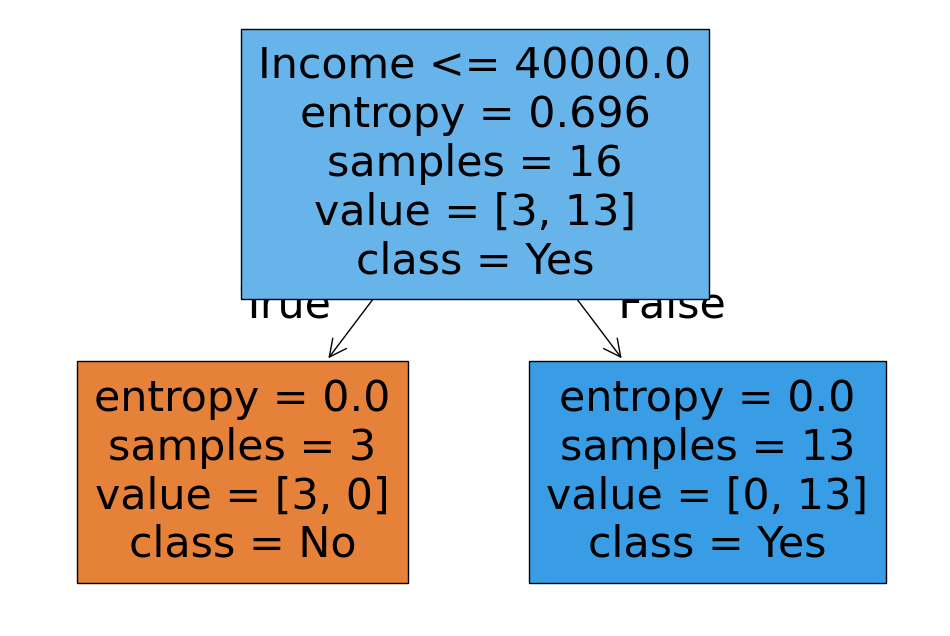

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))

plot_tree(
    model,
    feature_names=['Age', 'Income'],
    class_names=['No', 'Yes'],
    filled=True
)

plt.show()